In [1]:
import pandas as pd
import numpy as np

In [2]:
dataset=pd.read_csv("/content/salary.csv")

In [4]:
print(dataset.shape)
print(dataset.tail())

(32561, 5)
       age  education.num  capital.gain  hours.per.week income
32556   22             10             0              40  <=50K
32557   27             12             0              38  <=50K
32558   40              9             0              40   >50K
32559   58              9             0              40  <=50K
32560   22              9             0              20  <=50K


In [5]:
income_set=set(dataset['income'])
dataset['income']=dataset['income'].map({'<=50K':0,'>50K':1}).astype(int)
print(dataset.head())

   age  education.num  capital.gain  hours.per.week  income
0   90              9             0              40       0
1   82              9             0              18       0
2   66             10             0              40       0
3   54              4             0              40       0
4   41             10             0              40       0


In [6]:
X=dataset.iloc[:,:-1].values
X

array([[90,  9,  0, 40],
       [82,  9,  0, 18],
       [66, 10,  0, 40],
       ...,
       [40,  9,  0, 40],
       [58,  9,  0, 40],
       [22,  9,  0, 20]])

In [7]:
y=dataset.iloc[:,-1].values
y

array([0, 0, 0, ..., 1, 0, 0])

In [8]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=0)



In [9]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

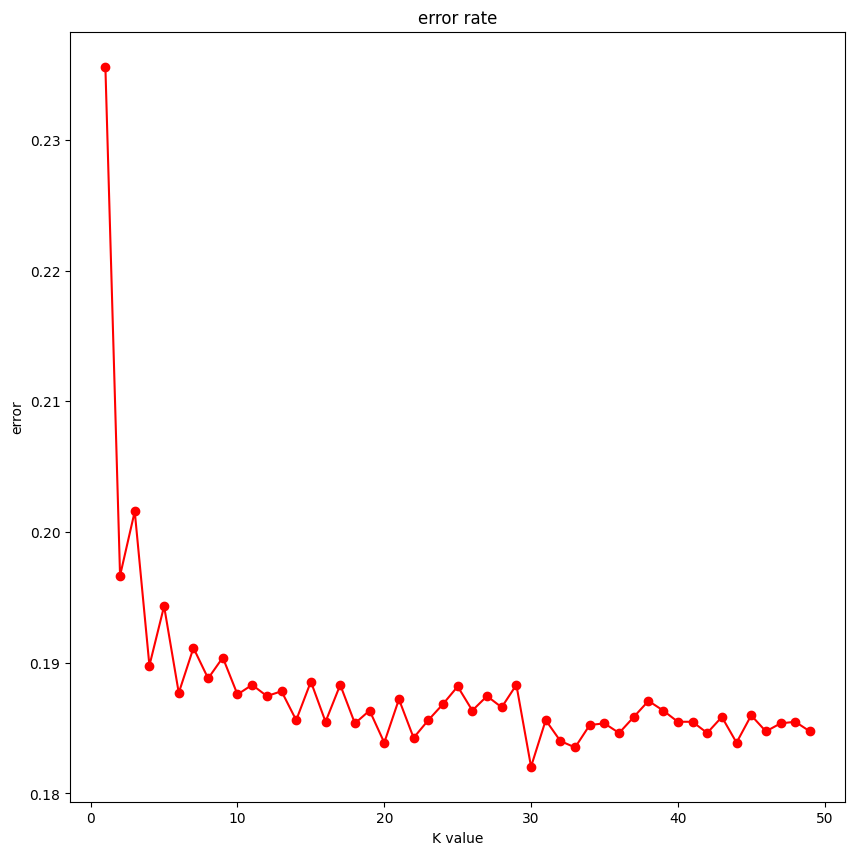

In [21]:
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
error=[]
for i in range(1,50):
  model=KNeighborsClassifier(n_neighbors=i)
  model.fit(X_train,y_train)
  y_pred=model.predict(X_test)
  error.append(np.mean(y_pred!=y_test))
plt.figure(figsize=(10,10))
plt.plot(range(1,50),error,color='r',marker='o')
plt.title('error rate')
plt.xlabel('K value')
plt.ylabel('error')
plt.show()

In [28]:
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=30,metric='minkowski',p=2)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
y_pred


array([0, 0, 0, ..., 0, 0, 1])

In [29]:
from sklearn.metrics import confusion_matrix,accuracy_score
cf=confusion_matrix(y_test,y_pred)
print(cf)
print("accuracy score:{0}".format(accuracy_score(y_test,y_pred)*100))


[[5875  318]
 [1164  784]]
accuracy score:81.79584817589976
